# LangGraph + Qdrant Hybrid Search + Open-Source Reranking

A hands-on notebook covering:
- LangGraph fundamentals
- Dense + sparse (hybrid) retrieval with Qdrant
- Open-source cross-encoder reranking
- Wiring it all into a LangGraph agent with OpenAI for generation

**Environment:** Google Colab

**Generation LLM:** OpenAI (via API key stored in Colab Secrets)

**Embeddings / Reranker:** Open-source, run locally in the notebook (no extra API cost)


---
## 1. LangGraph Introduction

### 1.1 What is LangGraph?

LangGraph is a library built on top of LangChain for constructing **stateful, multi-step, and potentially cyclic** applications with LLMs. Where a typical LangChain "chain" (built with LCEL) is a fairly linear pipeline - input goes in one end, output comes out the other - LangGraph lets you model your application as a **graph of nodes and edges**, with an explicit, shared **state** object that flows through the graph and gets updated at each step.

> 📌 **Correction, cross-checked against the official LangGraph docs (`overview.md` in the linked knowledge base):** calling LangGraph "a library built on top of LangChain" undersells it slightly. The current official framing is that LangGraph is **"a low-level orchestration framework and runtime for building, managing, and deploying long-running, stateful agents"** — it's a standalone framework in the same family as LangChain (same maintainer, interoperable, often used together), not merely an add-on that sits on top of it. In plain terms: LangChain gives you pre-built building blocks (chains, prompts, retrievers); LangGraph gives you the **control structure** — the graph, the state, the loop — that decides *when and in what order* those building blocks (or raw LLM calls, or your own Python functions) get used. You can use LangGraph with or without LangChain components inside its nodes.

This matters for agentic systems because real agent behavior is rarely linear:
- An agent might need to **loop** (retrieve → check if enough info → retrieve again)
- An agent might need to **branch** (if the query is a greeting, skip retrieval entirely)
- An agent might need to **pause and resume** (human-in-the-loop approval before taking an action)

LangGraph is designed to make these patterns first-class citizens instead of workarounds.

### 1.2 Core Concepts

| Concept | Description |
|---|---|
| **State** | A shared data structure (typically a `TypedDict` or Pydantic model) that represents the "memory" of the graph at any point in execution. Every node reads from and writes to this state. |
| **Node** | A Python function (or callable) that takes the current state, does some work (call an LLM, run retrieval, call a tool), and returns a partial update to the state. Per the official docs: *"nodes do the work, edges tell what to do next."* |
| **Edge** | A connection between two nodes, defining execution order. Edges can be **normal** (always go from A to B) or **conditional** (go to B or C depending on the state). |
| **Graph compilation** | You define nodes and edges on a `StateGraph` object, then call `.compile()` to turn it into a runnable object (a `CompiledGraph`). The docs are explicit that this step is not optional: *"You **MUST** compile your graph before you can use it."* Compiling also runs basic structural checks (e.g., catching orphaned nodes with no path to them). |
| **START / END** | Special reserved nodes marking entry and exit points of the graph. `START` is described in the docs as *"a special node that represents the node that sends user input to the graph."* |

### 1.3 StateGraph vs. a Simple Chain

A simple LCEL chain looks like:

```
prompt | llm | output_parser
```

This is a **DAG (Directed Acyclic Graph)** - strictly linear, no branching, no loops, no shared mutable state beyond what's explicitly piped forward.

A `StateGraph` in LangGraph looks more like:

```
        ┌────────────┐
        │   START    │
        └─────┬──────┘
              ▼
        ┌────────────┐
        │  retrieve  │
        └─────┬──────┘
              ▼
        ┌────────────┐
        │   rerank   │
        └─────┬──────┘
              ▼
        ┌────────────┐
        │  generate  │
        └─────┬──────┘
              ▼
        ┌────────────┐
        │    END     │
        └────────────┘
```

Every node reads/writes a **shared, typed state object** - so `generate` can see not just the immediate previous output, but anything accumulated earlier in the run (e.g., the original query, retrieved docs, rerank scores, intermediate reasoning).

### 1.4 Conditional Edges & Cycles

LangGraph supports **conditional edges** - a routing function inspects the state and decides which node to go to next. This is what enables things like:
- "If retrieval returned zero results, go to a `clarify` node instead of `generate`"
- "If the agent decides it needs another tool call, loop back to the `tool` node instead of ending"

This cyclic capability is the key structural difference from LCEL chains, which cannot loop.

> 📌 **Addition, from the knowledge base's `thinking-in-langgraph.md`:** the version above (a separate routing function wired in with `add_conditional_edges`) is the classic pattern used in this notebook. The docs also describe a newer, sometimes simpler alternative: a node can return a **`Command` object** that names its *own* next destination directly, instead of a separate external routing function deciding for it. Same end result (dynamic, state-based routing), just decided *inside* the node rather than *between* nodes — worth knowing both exist, so you can pick whichever reads more clearly for a given graph.

LangGraph also supports **checkpointing** (persisting state at each step, enabling resumability, time travel, and human-in-the-loop interrupts) - we won't use this deeply in this notebook, but it's worth knowing it exists for production agent systems.

### 1.5 LangGraph vs. LangChain - Summary

| | LangChain (LCEL chains) | LangGraph |
|---|---|---|
| **Structure** | Linear DAG | Arbitrary graph (can cycle) |
| **State** | Implicit, passed via pipe `|` | Explicit, typed, shared state object |
| **Branching** | Limited (`RunnableBranch`) | First-class conditional edges |
| **Loops** | Not supported natively | Native support |
| **Best for** | Simple retrieval-augmented generation, prompt pipelines | Agents, multi-step reasoning, tool-calling loops, human-in-the-loop workflows |

### 1.6 When to Reach for LangGraph

Use a plain LCEL chain when your pipeline is genuinely linear (retrieve → prompt → generate, no branching).

Reach for LangGraph when you need:
- Multiple steps that might need to repeat (agent loops)
- Conditional routing based on intermediate results
- Explicit, inspectable state that multiple steps read/write
- Human-in-the-loop interrupts or persistence across sessions

This notebook technically has a **linear** pipeline (retrieve → rerank → generate), but we build it in LangGraph anyway - partly for teaching purposes, and partly because it's the natural extension point if you later want to add conditional branches (e.g., "skip rerank if fewer than 3 docs retrieved").


---
## 2. Setup & Environment

We'll install:
- `langgraph`, `langchain`, `langchain-openai` - orchestration + OpenAI generation
- `qdrant-client`, `langchain-qdrant` - vector DB
- `fastembed` - open-source dense + sparse embedding models (runs locally, CPU-friendly)
- `sentence-transformers` - open-source cross-encoder reranker

### API Key via Google Colab Secrets

This notebook is designed for **Google Colab**. Store your OpenAI API key using Colab's built-in **Secrets** manager rather than hardcoding it:

1. Click the 🔑 **key icon** in the left sidebar of Colab
2. Add a new secret named `OPENAI_API_KEY`
3. Paste your key as the value
4. Toggle **"Notebook access"** ON for this notebook

The code below reads it via `google.colab.userdata`.


### 📦 Cell 0 — Install the stack: LangGraph, Qdrant, and open-source embedding/reranking libraries

Installs the orchestration layer (`langgraph`, `langchain`), the vector database client (`qdrant-client`, `langchain-qdrant`), and two open-source model libraries that run locally with no extra API cost: `fastembed` (dense + sparse embeddings) and `sentence-transformers` (the cross-encoder reranker). Only the final generation step uses a paid API (OpenAI) — everything else here runs on CPU, for free.

In [1]:
# Install dependencies
!pip install -q langgraph langchain langchain-openai langchain-core \
    qdrant-client langchain-qdrant \
    fastembed sentence-transformers


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 🔑 Cell 1 — Load the OpenAI key from Colab Secrets

Reads the API key from Colab's Secrets manager instead of hardcoding it into the notebook — the key only gets used later, for the final `generate` step where an actual LLM call happens; every retrieval/reranking step in this notebook runs entirely offline.

In [2]:
# --- OpenAI API key from local environment variable ---
import os

# Reads the key directly from the environment. Set it beforehand, e.g.:
#   Windows (PowerShell): $env:OPENAI_API_KEY = "sk-..."
#   macOS/Linux:           export OPENAI_API_KEY="sk-..."
assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found in environment - set it before running this notebook."
print("OpenAI API key found in environment ✔")


OpenAI API key found in environment ✔


### 🧰 Cell 2 — Import the full toolkit

Brings in everything used across the notebook: `TypedDict`/`List`/`Optional` for defining the shared LangGraph state, `QdrantClient` + `qmodels` for the vector database, `TextEmbedding`/`SparseTextEmbedding` from FastEmbed for dense and sparse embeddings, `CrossEncoder` for reranking, and `StateGraph`/`START`/`END` to wire the pipeline together as a graph.

In [4]:
# Type hints used for defining state schemas and improving code readability.
# - TypedDict: Creates strongly-typed dictionary structures.
# - List: Represents a list of objects.
# - Optional: Indicates that a value may be None.
from typing import TypedDict, List, Optional

# NumPy is used for numerical operations and vector manipulations.
import numpy as np

# Qdrant client for interacting with the vector database.
# - QdrantClient: Connects to the Qdrant server.
# - qmodels: Contains helper models for collections, search parameters, etc.
from qdrant_client import QdrantClient, models as qmodels

# FastEmbed provides lightweight embedding models.
# - TextEmbedding: Generates dense vector embeddings.
# - SparseTextEmbedding: Generates sparse embeddings for hybrid search.
from fastembed import TextEmbedding, SparseTextEmbedding

# CrossEncoder is used for reranking retrieved documents by
# computing relevance scores between the query and documents.
from sentence_transformers import CrossEncoder

# ChatOpenAI provides access to OpenAI chat models through LangChain.
from langchain_openai import ChatOpenAI

# LangGraph components used to define stateful AI workflows.
# - StateGraph: Creates a graph-based workflow.
# - START: Entry point of the graph.
# - END: Exit point of the graph.
from langgraph.graph import StateGraph, START, END

---
## 3. Embedding & Sparse Vector Setup

For **hybrid search** we need two kinds of representations for each document:

- **Dense embeddings** - capture semantic similarity (meaning-based). We use `BAAI/bge-small-en-v1.5` via `fastembed`, a small, fast, open-source model good for CPU inference.
- **Sparse embeddings** - capture lexical/keyword overlap, similar in spirit to BM25 but learned. We use `Qdrant/bm25` (a sparse text embedding available directly through `fastembed`), which behaves like classic BM25 term-weighting without needing a separate keyword index.

**Why hybrid?** Dense embeddings are great at semantic matches ("car" ~ "automobile") but can miss exact keyword matches (product codes, names, acronyms). Sparse embeddings are great at exact term matches but miss semantic similarity. Combining both, via **fusion**, tends to outperform either alone.


### 🔤 Cell 3 — Load the dense and sparse embedding models

`BAAI/bge-small-en-v1.5` (dense) captures *meaning* — it knows "car" and "automobile" are related even without shared words. `Qdrant/bm25` (sparse) captures *exact terms* — like a specific model name or code — the classic weakness of pure dense search. This is the same hybrid-search foundation covered in *Retrieval Optimization Techniques*: each method covers the other's blind spot.

In [5]:
# Initialize the dense embedding model.
# This model converts text into dense numerical vectors that capture
# the semantic meaning of the input text.
#
# Model:
#   BAAI/bge-small-en-v1.5
# Framework:
#   FastEmbed (ONNX-based, runs locally without external API calls)
dense_model = TextEmbedding(model_name="BAAI/bge-small-en-v1.5")

# The dimensionality of embeddings produced by the BGE Small model.
# Every text is represented as a 384-dimensional vector.
DENSE_DIM = 384

# Initialize the sparse embedding model.
# Sparse embeddings work similarly to traditional keyword-based retrieval
# (BM25), assigning importance scores to individual terms.
#
# This is commonly used alongside dense embeddings to implement
# Hybrid Search for improved retrieval performance.
sparse_model = SparseTextEmbedding(model_name="Qdrant/bm25")

# Display the names of the loaded embedding models to verify
# that initialization completed successfully.
print("Dense model loaded:", dense_model.model_name)
print("Sparse model loaded:", sparse_model.model_name)

Dense model loaded: BAAI/bge-small-en-v1.5
Sparse model loaded: Qdrant/bm25


### 🧱 Cell 4 — Wrap both models in simple helper functions, then smoke-test them

`embed_dense()` and `embed_sparse()` just call the two models and convert their output into plain Python lists (Qdrant expects that format, not raw NumPy arrays). The last few lines run one sample sentence through both, printing the vector length (384 for dense) and how many non-zero terms the sparse embedding found — a quick sanity check that both models actually loaded correctly before building anything on top of them.

In [9]:
def embed_dense(texts: List[str]) -> List[List[float]]:
    """
    Generate dense vector embeddings for a list of text documents.

    Parameters:
        texts (List[str]):
            A list of input strings to be converted into dense embeddings.

    Returns:
        List[List[float]]:
            A list of dense vectors, where each vector is represented
            as a Python list of floating-point values.

    Note:
        FastEmbed returns NumPy arrays, which are converted to Python
        lists for easier serialization and compatibility with Qdrant.
    """
    return [vec.tolist() for vec in dense_model.embed(texts)]


def embed_sparse(texts: List[str]):
    """
    Generate sparse embeddings for a list of text documents.

    Parameters:
        texts (List[str]):
            A list of input strings.

    Returns:
        List:
            A list of sparse embedding objects containing:
            - indices : Positions of non-zero terms
            - values  : Importance score for each term

    Note:
        Sparse embeddings are primarily used for keyword-based retrieval
        and are often combined with dense embeddings to perform
        Hybrid Search.
    """
    return list(sparse_model.embed(texts))

# SMOKE TEST

# Sample text for verifying that both embedding models
# are working correctly.
sample = [
    "LangGraph makes it easy to build stateful, cyclic LLM applications."
]

# Generate dense and sparse embeddings.
d = embed_dense(sample)
s = embed_sparse(sample)

# Display basic information about the generated embeddings.
print("Dense vector length:", len(d[0]))          # Expected: 384
print("Sparse non-zero terms:", len(s[0].indices))
print(s[0].values)

Dense vector length: 384
Sparse non-zero terms: 8
[1.65647059 1.65647059 1.65647059 1.65647059 1.65647059 1.65647059
 1.65647059 1.65647059]


---
## 4. Qdrant Collection Setup

We use an **in-memory Qdrant instance** (`QdrantClient(":memory:")`) so the notebook runs end-to-end in Colab with no external service. In production you'd point this at a running Qdrant server or Qdrant Cloud instead - the rest of the code is identical.

Qdrant supports **named vectors** per point, which is exactly what we need for hybrid search: each document gets a `"dense"` vector and a `"sparse"` vector stored side-by-side in the same collection.


### 🗄️ Cell 5 — Create an in-memory Qdrant collection with two named vector slots

`QdrantClient(":memory:")` keeps everything in RAM — nothing survives past this notebook session, which is fine for a demo (swap it for a real server URL in production, same code otherwise). The collection is configured with **two named vectors per point** — `dense` and `sparse` — rather than two separate databases, which is exactly the approach the *Legal Query Resolution* system used: one collection, two searchable representations of the same content.

In [10]:
# Name of the collection that will store our documents.
# A collection in Qdrant is similar to a table in a relational database.
COLLECTION_NAME = "langgraph_hybrid_demo"

# Create an in-memory Qdrant instance.
# Using ":memory:" stores the database in RAM, making it ideal for
# demonstrations, tutorials, and experimentation.
#
# Note:
# The data will be lost once the Python session ends.
client = QdrantClient(":memory:")

# Create a new collection capable of storing both
# dense and sparse embeddings for Hybrid Search.
client.create_collection(
    collection_name=COLLECTION_NAME,

    # Configuration for dense vector embeddings.
    # These vectors capture the semantic meaning of the documents.
    vectors_config={
        "dense": qmodels.VectorParams(
            size=DENSE_DIM,                     # Dimension of dense vectors (384)
            distance=qmodels.Distance.COSINE    # Similarity metric for vector search
        ),
    },

    # Configuration for sparse vectors.
    # Sparse vectors enable keyword-based retrieval similar to BM25.
    sparse_vectors_config={
        "sparse": qmodels.SparseVectorParams(),
    },
)

# Confirm successful collection creation.
print(
    f"Collection '{COLLECTION_NAME}' created with dense + sparse named vectors."
)

Collection 'langgraph_hybrid_demo' created with dense + sparse named vectors.


### Sample Corpus

A small, self-contained set of ~18 short documents about AI/ML/agent topics - enough to see meaningful differences between dense, sparse, and hybrid search without needing external files.


### 📚 Cell 6 — Define a small, self-contained sample corpus

About 18 short documents on LangGraph/Qdrant/RAG topics, each tagged with a `topic` field (usable later for metadata filtering). Small enough to read every result by eye, which makes it easy to actually see the difference between dense, sparse, and hybrid search further down.

In [11]:
documents = [
    {"id": 0, "text": "LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.", "topic": "langgraph"},
    {"id": 1, "text": "A StateGraph in LangGraph defines nodes, edges, and a shared state object that flows through the graph.", "topic": "langgraph"},
    {"id": 2, "text": "Unlike LCEL chains, which are directed acyclic graphs, LangGraph supports cycles and conditional branching.", "topic": "langgraph"},
    {"id": 3, "text": "Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search.", "topic": "qdrant"},
    {"id": 4, "text": "Qdrant supports named vectors, allowing multiple embeddings (e.g., dense and sparse) to be stored per point.", "topic": "qdrant"},
    {"id": 5, "text": "Hybrid search combines dense semantic vectors with sparse lexical vectors to improve retrieval accuracy.", "topic": "hybrid_search"},
    {"id": 6, "text": "Reciprocal Rank Fusion (RRF) is a common method for merging ranked lists from multiple retrieval systems.", "topic": "hybrid_search"},
    {"id": 7, "text": "BM25 is a classic sparse retrieval algorithm based on term frequency and inverse document frequency.", "topic": "hybrid_search"},
    {"id": 8, "text": "Dense embeddings encode semantic meaning, allowing retrieval of conceptually similar text even without shared keywords.", "topic": "embeddings"},
    {"id": 9, "text": "Cross-encoder rerankers score a query-document pair jointly, producing more accurate relevance scores than bi-encoders.", "topic": "reranking"},
    {"id": 10, "text": "BAAI/bge-reranker-base is an open-source cross-encoder model commonly used for reranking retrieved passages.", "topic": "reranking"},
    {"id": 11, "text": "Reranking is typically applied to a small candidate set (e.g., top 20-50) after initial retrieval, since cross-encoders are more compute-intensive.", "topic": "reranking"},
    {"id": 12, "text": "Agentic RAG systems combine retrieval-augmented generation with agent-style decision making, such as deciding whether to retrieve at all.", "topic": "agents"},
    {"id": 13, "text": "LangGraph's checkpointing feature allows persisting graph state, enabling resumability and human-in-the-loop workflows.", "topic": "langgraph"},
    {"id": 14, "text": "Conditional edges in LangGraph route execution to different nodes based on the current state, enabling dynamic control flow.", "topic": "langgraph"},
    {"id": 15, "text": "Open-source embedding models like bge-small-en-v1.5 can run efficiently on CPU, making them practical for local development.", "topic": "embeddings"},
    {"id": 16, "text": "Vector databases like Qdrant, Weaviate, and Milvus are optimized for approximate nearest neighbor search at scale.", "topic": "qdrant"},
    {"id": 17, "text": "SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.", "topic": "hybrid_search"},
]

print(f"Corpus size: {len(documents)} documents")

Corpus size: 18 documents


---
## 5. Ingestion Pipeline

For this small corpus we treat each document as a single chunk (no further splitting needed). In a real-world pipeline, you'd typically chunk longer documents first (e.g., via `RecursiveCharacterTextSplitter`), then embed each chunk.

Steps:
1. Generate dense embeddings for all documents
2. Generate sparse embeddings for all documents
3. Upsert into Qdrant as points with both named vectors + payload metadata


### ⬆️ Cell 7 — Embed every document twice, then upload it into Qdrant

For each of the 18 documents, this generates *both* a dense and a sparse embedding, then builds a `PointStruct` bundling the document's `id`, both vectors (under their `dense`/`sparse` names), and its metadata (`payload`) — this payload is what actually gets returned in search results later. `client.upsert()` writes everything in, matching the exact payload pattern from the Legal Query Resolution notebook: store the vectors *and* the retrievable metadata side by side in the same point.

In [12]:
# Extract the text content from each document.
# These texts will be converted into embeddings for storage.
texts = [d["text"] for d in documents]

# Generate dense embeddings.
# Dense vectors capture the semantic meaning of each document.
dense_vectors = embed_dense(texts)

# Generate sparse embeddings.
# Sparse vectors capture keyword importance for lexical matching.
sparse_vectors = embed_sparse(texts)

# Prepare a list of Qdrant Point objects.
# Each point represents a single document stored in the vector database.
points = []

for doc, dense_vec, sparse_vec in zip(documents, dense_vectors, sparse_vectors):

    # Create a PointStruct containing:
    # - Unique document ID
    # - Dense embedding
    # - Sparse embedding
    # - Metadata (payload)
    points.append(
        qmodels.PointStruct(
            id=doc["id"],

            # Store multiple named vectors for Hybrid Search.
            vector={
                "dense": dense_vec,

                "sparse": qmodels.SparseVector(
                    indices=sparse_vec.indices.tolist(),
                    values=sparse_vec.values.tolist(),
                ),
            },

            # Store additional metadata that can be retrieved
            # along with the search results.
            payload={
                "text": doc["text"],
                "topic": doc["topic"],
            },
        )
    )

# Insert (or update) all points into the Qdrant collection.
#
# Upsert performs:
# - Insert if the point ID does not exist.
# - Update if the point ID already exists.
client.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
)

# Display the number of documents successfully stored.
print(f"Upserted {len(points)} points into '{COLLECTION_NAME}'.")

Upserted 18 points into 'langgraph_hybrid_demo'.


---
## 6. Hybrid Search in Qdrant

We'll compare three retrieval modes for the same query:

1. **Dense-only** - pure semantic vector search
2. **Sparse-only** - pure lexical/BM25-style search
3. **Hybrid** - dense + sparse combined via Qdrant's **Query API** using **RRF (Reciprocal Rank Fusion)**

Qdrant's `query_points` supports a `prefetch` list (candidate generation from each vector type) plus a top-level fusion query that merges the ranked lists.


### 🔍 Cell 8 — Define three retrieval functions: dense-only, sparse-only, and hybrid

`dense_search()` and `sparse_search()` each query just one of the two vector types. `hybrid_search()` is the interesting one: it runs *both* searches independently as `prefetch` candidates, then merges the two ranked lists using `Fusion.RRF` — **Reciprocal Rank Fusion**, the positional-only merging method covered earlier (it only looks at *rank position* in each list, never the raw similarity/BM25 scores, which is exactly why it can combine two differently-scaled scoring systems fairly).

In [16]:
def dense_search(query: str, top_k: int = 5):
    """
    Perform semantic (dense) vector search.

    The user query is converted into a dense embedding and compared
    against the dense vectors stored in Qdrant using cosine similarity.

    Parameters:
        query (str):
            User's search query.

        top_k (int):
            Number of most relevant documents to return.

    Returns:
        List[ScoredPoint]:
            Ranked search results based on semantic similarity.
    """

    # Convert the query into a dense embedding.
    q_vec = embed_dense([query])[0]

    # Search the dense vector index.
    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=q_vec,
        using="dense",
        limit=top_k,
    )

    return results.points


def sparse_search(query: str, top_k: int = 5):
    """
    Perform keyword-based (sparse) search.

    The query is converted into a sparse embedding and matched
    against sparse vectors stored in Qdrant.

    Parameters:
        query (str):
            User's search query.

        top_k (int):
            Number of documents to retrieve.

    Returns:
        List[ScoredPoint]:
            Ranked search results based on lexical similarity.
    """

    # Generate sparse embedding for the query.
    q_sparse = embed_sparse([query])[0]

    # Search the sparse vector index.
    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=qmodels.SparseVector(
            indices=q_sparse.indices.tolist(),
            values=q_sparse.values.tolist(),
        ),
        using="sparse",
        limit=top_k,
    )

    return results.points


def hybrid_search(query: str, top_k: int = 5, prefetch_k: int = 20):
    """
    Perform Hybrid Search using Reciprocal Rank Fusion (RRF).

    Hybrid Search combines:
        1. Dense Search (semantic similarity)
        2. Sparse Search (keyword matching)

    Qdrant first retrieves candidates from both indexes and then
    merges them using Reciprocal Rank Fusion (RRF), producing a
    more robust ranking than either method alone.

    Parameters:
        query (str):
            User's search query.

        top_k (int):
            Number of final search results to return.

        prefetch_k (int):
            Number of candidate documents retrieved independently
            from each search method before fusion.

    Returns:
        List[ScoredPoint]:
            Top-ranked documents after combining dense and sparse search.
    """

    # Generate dense and sparse embeddings for the query.
    q_vec = embed_dense([query])[0]
    q_sparse = embed_sparse([query])[0]

    # Execute Hybrid Search.
    results = client.query_points(
        collection_name=COLLECTION_NAME,

        # Retrieve candidates independently from both indexes.
        prefetch=[
            qmodels.Prefetch(
                query=q_vec,
                using="dense",
                limit=prefetch_k,
            ),

            qmodels.Prefetch(
                query=qmodels.SparseVector(
                    indices=q_sparse.indices.tolist(),
                    values=q_sparse.values.tolist(),
                ),
                using="sparse",
                limit=prefetch_k,
            ),
        ],

        # Merge both rankings using Reciprocal Rank Fusion (RRF).
        query=qmodels.FusionQuery(
            fusion=qmodels.Fusion.RRF
        ),

        # Return the final top-k documents.
        limit=top_k,
    )

    return results.points

### ⚖️ Cell 9 — Run the same query through all three search modes, side by side

`show_results()` is just a pretty-printer. The real point of this cell is the comparison: the same question run through dense-only, sparse-only, and hybrid search will often return *different* top results — this is the concrete, hands-on version of the dense-vs-sparse trade-off discussed earlier: dense favors meaning-based matches, sparse favors exact keyword overlap, and hybrid usually blends the strengths of both.

In [20]:
def show_results(title: str, points):
    """
    Display retrieved search results in a readable format.

    Parameters:
        title (str):
            Heading displayed before the search results.

        points (List[ScoredPoint]):
            List of documents returned by the search function.

    Each result displays:
        - Retrieval score
        - Original document text
    """

    print(f"\n--- {title} ---")

    for p in points:
        # Round the score for better readability.
        score = round(p.score, 4) if p.score is not None else None

        # Display the retrieval score and document text.
        print(f"[{score}] {p.payload['text']}")


# =============================================================================
# COMPARE DENSE, SPARSE, AND HYBRID SEARCH
# =============================================================================

# Sample user query.
# This query is intentionally phrased as a natural language question
# to demonstrate the differences between retrieval strategies.
query = "What is Splade?"

# Execute Dense Search.
# Retrieves documents based on semantic similarity.
show_results(
    "Dense-only",
    dense_search(query)
)

# Execute Sparse Search.
# Retrieves documents based on keyword overlap.
show_results(
    "Sparse-only",
    sparse_search(query)
)

# Execute Hybrid Search.
# Combines Dense and Sparse retrieval using Reciprocal Rank Fusion (RRF)
# to produce more accurate and robust search results.
show_results(
    "Hybrid (RRF fusion)",
    hybrid_search(query)
)


--- Dense-only ---
[0.674] SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.
[0.4917] Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search.
[0.4695] LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.
[0.4617] BAAI/bge-reranker-base is an open-source cross-encoder model commonly used for reranking retrieved passages.
[0.4555] Open-source embedding models like bge-small-en-v1.5 can run efficiently on CPU, making them practical for local development.

--- Sparse-only ---
[2.752] SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.

--- Hybrid (RRF fusion) ---
[1.0] SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.
[0.3333] Qdrant is an open-source vector database written in Rus

### Observations

Try a query that leans more on exact keyword matching (e.g., mentioning `"BM25"` or `"BAAI/bge-reranker-base"` by name) versus one that's purely conceptual (e.g., `"how do vector databases find similar items"`). You should see:

- **Sparse-only** favors documents with literal keyword/term overlap
- **Dense-only** favors documents that are semantically related even without shared words
- **Hybrid** tends to blend the strengths of both, especially useful when queries mix specific terms with conceptual intent


---
## 7. Open-Source Reranking

Initial retrieval (dense, sparse, or hybrid) is optimized for **recall over a large corpus** - it's fast but approximate. A **cross-encoder reranker** re-scores a smaller candidate set by jointly encoding the (query, document) pair, which is more accurate but too slow to run over an entire corpus.

Typical pipeline: retrieve top-K (e.g., 20) candidates cheaply → rerank down to top-N (e.g., 3-5) with a cross-encoder → pass those to the LLM.

We use `cross-encoder/ms-marco-MiniLM-L-6-v2`, a small, fast, open-source cross-encoder well-suited for CPU inference in a notebook. (`BAAI/bge-reranker-base` is a stronger but heavier alternative - swap the model name below if you have GPU access.)


### 🎯 Cell 10 — Load a cross-encoder, and define the reranking step

`cross-encoder/ms-marco-MiniLM-L-6-v2` is a **cross-encoder** — unlike the bi-encoder models used for dense search, it reads the query and one candidate document *together* in a single pass, which is far more accurate but too slow to run over an entire corpus. That's why `rerank()` only ever gets called on a small candidate list (the top-K from hybrid search), never the full 18-document corpus — exactly the bi-encoder-casts-a-wide-net, cross-encoder-refines-the-shortlist pattern from earlier.

In [21]:
# Initialize a CrossEncoder model for reranking retrieved documents.
#
# Unlike embedding models, a CrossEncoder jointly processes the
# query and document to produce a highly accurate relevance score.
#
# Although slower than vector search, CrossEncoders provide
# significantly better ranking quality and are typically applied
# only to the top retrieved candidates.
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(
    query: str,
    candidates: List[qmodels.ScoredPoint],
    top_n: int = 3,
):
    """
    Rerank retrieved documents using a CrossEncoder.

    Workflow:
        1. Create (query, document) pairs.
        2. Predict a relevance score for each pair.
        3. Sort documents by the predicted score.
        4. Return the top-ranked documents.

    Parameters:
        query (str):
            User's search query.

        candidates (List[ScoredPoint]):
            Documents retrieved from Dense, Sparse, or Hybrid Search.

        top_n (int):
            Number of highest-ranked documents to return.

    Returns:
        List[Tuple[ScoredPoint, float]]:
            A list containing:
            - The retrieved document
            - Its CrossEncoder relevance score
    """

    # Create (query, document) pairs required by the CrossEncoder.
    pairs = [
        (query, c.payload["text"])
        for c in candidates
    ]

    # Predict relevance scores for each pair.
    # Higher scores indicate stronger semantic relevance.
    scores = reranker.predict(pairs)

    # Sort candidate documents by their predicted relevance score
    # in descending order.
    reranked = sorted(
        zip(candidates, scores),
        key=lambda pair: pair[1],
        reverse=True,
    )

    # Return only the top-N highest ranked documents.
    return [
        (candidate, float(score))
        for candidate, score in reranked[:top_n]
    ]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3891.20it/s]


### 🔀 Cell 11 — See reranking actually change the ordering

Retrieves 10 candidates via hybrid search, prints them in their original RRF-fused order, then reranks down to the top 3 with the cross-encoder and prints that new order. If the top result changes position (or a lower-ranked candidate jumps to #1), that's the cross-encoder catching a relevance signal that pure vector similarity missed — proof the two-stage retrieve-then-rerank pipeline is doing real work, not just adding a step for nothing.

In [22]:
# Retrieve the top candidate documents using Hybrid Search.
#
# A larger candidate set (top_k=10) is retrieved so that the
# CrossEncoder has enough documents to accurately rerank.
candidates = hybrid_search(
    query,
    top_k=10,
)

# Display the retrieved documents before reranking.
# These documents are ordered according to Reciprocal Rank Fusion (RRF).
show_results(
    "Hybrid search candidates (pre-rerank)",
    candidates,
)

# Apply CrossEncoder reranking.
#
# The reranker evaluates each (query, document) pair independently
# and assigns a more accurate semantic relevance score.
reranked = rerank(
    query,
    candidates,
    top_n=3,
)

# DISPLAY FINAL RERANKED RESULTS
print("\n--- After reranking (top 3) ---")

# Display the highest-ranked documents after reranking.
for point, score in reranked:

    # Round the score for better readability.
    print(
        f"[{round(score, 4)}] {point.payload['text']}"
    )


--- Hybrid search candidates (pre-rerank) ---
[1.0] SPLADE is a sparse retrieval model that learns term expansions, unlike BM25 which relies purely on exact term matches.
[0.3333] Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search.
[0.25] LangGraph is a library for building stateful, multi-actor applications with LLMs, built on top of LangChain.
[0.2] BAAI/bge-reranker-base is an open-source cross-encoder model commonly used for reranking retrieved passages.
[0.1667] Open-source embedding models like bge-small-en-v1.5 can run efficiently on CPU, making them practical for local development.
[0.1429] Agentic RAG systems combine retrieval-augmented generation with agent-style decision making, such as deciding whether to retrieve at all.
[0.125] Reciprocal Rank Fusion (RRF) is a common method for merging ranked lists from multiple retrieval systems.
[0.1111] A StateGraph in LangGraph defines nodes, edges, and a shared state object th

Notice how the reranker can reorder results compared to the original hybrid fusion ranking - the cross-encoder looks at the query and document **together**, so it can catch relevance signals that vector similarity alone misses.


---
## 8. LangGraph Agent Construction

Now we wire retrieval → rerank → generate into a LangGraph `StateGraph`.

### 8.1 Define State

Our state carries everything downstream nodes might need: the original query, retrieved docs, reranked docs, and the final answer.


### 🗂️ Cell 12 — Define the shared state that flows through the LangGraph pipeline

`RAGState` is the "clipboard" every node in the graph reads from and writes to (the same concept as the *Legal Query Resolution* notebook's `RAGState`): it starts with just `query`, and each node downstream fills in one more field — `retrieved_docs`, then `reranked_docs`, then finally `answer` — nothing gets lost or recomputed between steps.

In [23]:
class RAGState(TypedDict):
    """
    Shared state passed between all nodes in the LangGraph workflow.

    Each node reads values from the state, performs its task,
    and returns updated values that are merged back into the state.

    Fields:
        query (str):
            The user's input question.

        retrieved_docs (List[dict]):
            Documents returned by the Hybrid Search step before
            reranking.

        reranked_docs (List[dict]):
            Top-ranked documents after CrossEncoder reranking.
            These are used as context for answer generation.

        answer (str):
            Final response generated by the Large Language Model (LLM).
    """
    query: str
    retrieved_docs: List[dict]      # raw hybrid search results
    reranked_docs: List[dict]       # top-N after reranking
    answer: str

### 8.2 Define Nodes

Each node is a plain function: it receives the current state and returns a dict of the fields it updates.


### ⚙️ Cell 13 — Define the three pipeline nodes, plus the LLM they'll use

Each node is a plain function: reads the current state, does one job, returns only the fields it updates. `retrieve_node` calls `hybrid_search()`; `rerank_node` re-scores those results with the cross-encoder from Cell 10; `generate_node` builds a prompt instructing the LLM to answer *only* from the reranked context (this is the **context assembly** step from earlier — deciding exactly what goes into the final prompt) and calls `llm.invoke()`. `temperature=0` makes the LLM's output deterministic — same input, same output every time, which matters for a demo you want to be reproducible.

In [24]:
# LANGGRAPH NODE 1: RETRIEVE DOCUMENTS

def retrieve_node(state: RAGState) -> dict:
    """
    Retrieve relevant documents using Hybrid Search.

    This node performs:
        1. Hybrid retrieval (Dense + Sparse Search)
        2. Converts Qdrant search results into a simplified format
           that can be passed through the graph state.

    Parameters:
        state (RAGState):
            Current workflow state containing the user's query.

    Returns:
        dict:
            Updated state containing the retrieved documents.
    """

    # Retrieve candidate documents using Hybrid Search.
    results = hybrid_search(
        state["query"],
        top_k=10,
    )

    # Extract only the information needed for downstream nodes.
    docs = [
        {
            "text": r.payload["text"],
            "topic": r.payload["topic"],
            "score": r.score,
        }
        for r in results
    ]

    return {
        "retrieved_docs": docs
    }

# LANGGRAPH NODE 2: RERANK DOCUMENTS

def rerank_node(state: RAGState) -> dict:
    """
    Rerank retrieved documents using a CrossEncoder.

    This node:
        1. Creates (query, document) pairs.
        2. Computes semantic relevance scores.
        3. Sorts documents by relevance.
        4. Keeps only the top-ranked documents.

    Parameters:
        state (RAGState):
            Current workflow state.

    Returns:
        dict:
            Updated state containing reranked documents.
    """

    # Create query-document pairs.
    pairs = [
        (state["query"], d["text"])
        for d in state["retrieved_docs"]
    ]

    # Predict semantic relevance scores.
    scores = reranker.predict(pairs)

    # Sort documents by descending relevance.
    combined = sorted(
        zip(state["retrieved_docs"], scores),
        key=lambda x: x[1],
        reverse=True,
    )

    # Keep only the top 3 documents.
    top_docs = [
        {
            **doc,
            "rerank_score": float(score),
        }
        for doc, score in combined[:3]
    ]

    return {
        "reranked_docs": top_docs
    }

# INITIALIZE THE LANGUAGE MODEL

# Create the LLM used for answer generation.
#
# Temperature = 0 makes the model deterministic,
# producing more consistent responses for RAG applications.
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

# LANGGRAPH NODE 3: GENERATE ANSWER

def generate_node(state: RAGState) -> dict:
    """
    Generate the final answer using the reranked documents.

    The node:
        1. Builds a context from the top-ranked documents.
        2. Creates a prompt instructing the LLM to answer
           using only the provided context.
        3. Generates the final response.

    Parameters:
        state (RAGState):
            Current workflow state.

    Returns:
        dict:
            Updated state containing the generated answer.
    """

    # Combine retrieved documents into a single context block.
    context = "\n".join(
        f"- {doc['text']}"
        for doc in state["reranked_docs"]
    )

    # Construct the prompt.
    prompt = (
        "Answer the question using only the context below. "
        "If the context is insufficient, say so.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {state['query']}\n\n"
        "Answer:"
    )

    # Generate the answer.
    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

### 8.3 Build & Compile the Graph

The pipeline here is linear (`retrieve → rerank → generate`), but expressing it in LangGraph means it's trivial to later add a conditional edge - e.g., skip `rerank_node` if `len(retrieved_docs) < 3`, or loop back to `retrieve_node` with a rewritten query if `generate_node` decides context was insufficient.


### 🕸️ Cell 14 — Wire the three nodes into an actual graph, and compile it

`add_node()` registers each function under a name; `add_edge()` defines the execution order — `START → retrieve → rerank → generate → END`, a purely linear chain in this notebook, but expressed as a graph rather than a fixed sequence, so a later change (like a conditional branch, covered in Section 10 below) only means adding one more edge, not restructuring the whole pipeline. `.compile()` turns this definition into something you can actually run.

In [25]:
# BUILD THE LANGGRAPH WORKFLOW

# Create a new LangGraph workflow using the RAGState schema.
#
# Every node in the graph will read from and write to this shared state.
graph_builder = StateGraph(RAGState)

# Register workflow nodes

# Node 1:
# Retrieves relevant documents from the vector database using
# Hybrid Search (Dense + Sparse retrieval).
graph_builder.add_node(
    "retrieve",
    retrieve_node,
)

# Node 2:
# Improves the ranking of retrieved documents using
# a CrossEncoder reranker.
graph_builder.add_node(
    "rerank",
    rerank_node,
)

# Node 3:
# Uses the reranked documents as context to generate
# the final answer with the LLM.
graph_builder.add_node(
    "generate",
    generate_node,
)

# Define execution flow

# Start the workflow by executing the retrieval node.
graph_builder.add_edge(
    START,
    "retrieve",
)

# After retrieval, rerank the retrieved documents.
graph_builder.add_edge(
    "retrieve",
    "rerank",
)

# Pass the reranked documents to the answer generation node.
graph_builder.add_edge(
    "rerank",
    "generate",
)

# End the workflow after the answer has been generated.
graph_builder.add_edge(
    "generate",
    END,
)

# Compile the graph

# Compile the workflow into an executable LangGraph application.
graph = graph_builder.compile()

# Confirm successful compilation.
print("Graph compiled ✔")

Graph compiled ✔


### 🖼️ Cell 15 — Draw the compiled graph as a diagram

Purely for visualization — `draw_mermaid_png()` renders the actual node-and-edge structure Cell 14 just built, so you can visually confirm the pipeline really is `retrieve → rerank → generate` before running it for real.

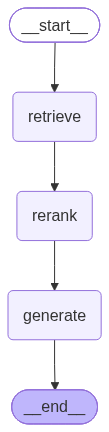

In [20]:
# Visualize the graph structure (Mermaid, rendered inline in Colab)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

---
## 9. Running the Graph

We invoke the compiled graph with an initial state containing just the `query` - the rest of the fields get filled in as execution proceeds through each node.


### ▶️ Cell 16 — Run the whole pipeline on a real question

`graph.invoke()` runs the query through all three nodes in sequence and returns the final `RAGState` — this cell just pulls out `query` and `answer` from that result to print them. This is the same one-line invocation the *DeepEval* companion notebook uses to generate real outputs to evaluate.

In [27]:
# The input to the graph is the initial workflow state,
# which contains only the user's query.
result = graph.invoke(
    {
        "query": "what is the meaning of wiki"
    }
)

# Display the original user query.
print("QUERY:", result["query"])

# Display the final answer generated by the LLM using
# the reranked retrieval context.
print("\nFINAL ANSWER:\n")
print(result["answer"])

QUERY: what is the meaning of wikipedia

FINAL ANSWER:

The context provided is insufficient to answer the question about the meaning of Wikipedia.


### Streaming Intermediate State

To make the retrieve → rerank → generate pipeline transparent (useful for teaching/debugging), we can use `.stream()` instead of `.invoke()` to see the state update after each node runs.


### 🎬 Cell 17 — Watch the state update after every single node

`.stream()` is the debugging-friendly alternative to `.invoke()` — instead of waiting for the whole pipeline to finish, it yields the state update after *each* node runs, one at a time. This makes each hop visible: you can literally watch `retrieved_docs` appear after retrieval, then get built on by `reranked_docs` after reranking, then `answer` appear last — useful for confirming the pipeline is doing what you think it's doing, node by node.

In [28]:
# Execute the graph in streaming mode.

# Instead of waiting for the entire workflow to complete,
# graph.stream() returns the output produced after each node
# executes. This is useful for:

# • Debugging workflow execution
# • Understanding how the graph updates its state
# • Visualizing intermediate results
# • Monitoring long-running pipelines

# Each iteration returns the state updates produced by a single node.
for step in graph.stream(
    {
        "query": "How does hybrid search combine dense and sparse retrieval?"
    }
):

    # Each streamed update contains a single node name
    # and the state changes produced by that node.
    node_name = list(step.keys())[0]
    node_output = step[node_name]

    print(f"\n=== After node: {node_name} ===")

    # Display the outputs generated by the current node.
    for key, value in node_output.items():

        # Retrieval node output.
        if key == "retrieved_docs":
            print(f"  retrieved_docs: {len(value)} docs")

        # Reranking node output.
        elif key == "reranked_docs":
            print(
                "  reranked_docs:",
                [
                    doc["text"][:60] + "..."
                    for doc in value
                ],
            )

        # Generation node output (or any future node outputs).
        else:
            print(f"  {key}: {value}")


=== After node: retrieve ===
  retrieved_docs: 10 docs

=== After node: rerank ===
  reranked_docs: ['Hybrid search combines dense semantic vectors with sparse le...', 'BM25 is a classic sparse retrieval algorithm based on term f...', 'SPLADE is a sparse retrieval model that learns term expansio...']

=== After node: generate ===
  answer: Hybrid search combines dense semantic vectors, which capture the meaning of the content, with sparse lexical vectors, which focus on specific terms, to improve retrieval accuracy.


### 🧬 Cell 17b — Watch the *entire* shared state grow after each node (not just the delta)

Cell 17's `.stream()` call used the default `stream_mode="updates"`, which only shows what each node *changed* — not the full picture. Passing `stream_mode="values"` instead makes `.stream()` yield the **complete, current `RAGState` object** after every node runs, so you can literally watch it accumulate: starts with only `query` → gains `retrieved_docs` → gains `reranked_docs` (on top of the previous fields, nothing is lost) → gains `answer`. This is the clearest possible demonstration of "one shared state object that every node reads from and writes to."

In [ ]:
# stream_mode="values" yields the FULL state after each node,
# instead of just that node's delta (which is what plain .stream() gave us in Cell 17).
#
# This lets us watch RAGState literally accumulate field by field:
#   {query}
#   -> {query, retrieved_docs}
#   -> {query, retrieved_docs, reranked_docs}
#   -> {query, retrieved_docs, reranked_docs, answer}

for i, full_state in enumerate(
    graph.stream(
        {"query": "How does hybrid search combine dense and sparse retrieval?"},
        stream_mode="values",
    )
):
    print(f"\n=== State snapshot #{i} (fields present so far: {list(full_state.keys())}) ===")

    for key, value in full_state.items():

        if key == "retrieved_docs":
            print(f"  retrieved_docs: {len(value)} docs")

        elif key == "reranked_docs":
            print(
                "  reranked_docs:",
                [doc["text"][:60] + "..." for doc in value],
            )

        elif key == "answer":
            print(f"  answer: {value}")

        else:
            print(f"  {key}: {value}")

### 🧪 Cell 18 — Run a few more questions through the full pipeline back-to-back

Just a loop calling `graph.invoke()` on three more sample questions — a quick way to eyeball whether the pipeline holds up across different phrasings and topics, not a single cherry-picked example.

In [29]:
# Try a few more queries end-to-end
test_queries = [
    "What open-source model can be used for reranking retrieved documents?",
    "Why would I use RRF fusion instead of dense search alone?",
    "What is Qdrant and what makes it different from a regular database?",
]

for q in test_queries:
    out = graph.invoke({"query": q})
    print(f"\nQ: {q}\nA: {out['answer']}\n{'-'*80}")


Q: What open-source model can be used for reranking retrieved documents?
A: BAAI/bge-reranker-base is an open-source model that can be used for reranking retrieved documents.
--------------------------------------------------------------------------------

Q: Why would I use RRF fusion instead of dense search alone?
A: You would use RRF fusion instead of dense search alone to combine ranked lists from multiple retrieval systems, potentially improving retrieval accuracy by leveraging the strengths of different methods. RRF can enhance the results by integrating diverse perspectives from various retrieval systems, which may capture different aspects of the data that dense search alone might miss.
--------------------------------------------------------------------------------

Q: What is Qdrant and what makes it different from a regular database?
A: Qdrant is an open-source vector database written in Rust, optimized for high-performance similarity search. It differs from a regular datab

---
## 10. Extensions

A few directions to take this further:

**Swapping components**
- Try a stronger dense embedder (e.g., `BAAI/bge-base-en-v1.5` or `intfloat/e5-large-v2`) for better recall at the cost of latency
- Try `BAAI/bge-reranker-base` or `BAAI/bge-reranker-large` instead of the MiniLM cross-encoder for higher rerank quality (GPU recommended)
- Swap `Qdrant/bm25` for a learned sparse model like SPLADE if you want term expansion rather than exact matching

**Adding memory / multi-turn**
- Add a `chat_history` field to `RAGState` and pass prior turns into the `generate_node` prompt
- Use LangGraph's checkpointing (`MemorySaver` or a persistent checkpointer) to maintain state across separate `.invoke()` calls, enabling true multi-turn conversations

**Conditional branching (a natural next step)**
- Add a conditional edge after `retrieve_node`: if `len(retrieved_docs) == 0` (or all scores are below a threshold), route to a `clarify_node` that asks the user to rephrase, instead of proceeding to `rerank`/`generate`
- Add a self-check loop: after `generate_node`, have the LLM judge whether the answer is well-supported by context; if not, loop back to `retrieve_node` with a reformulated query (classic **corrective RAG** pattern)

**Production considerations**
- **Latency**: cross-encoder reranking adds latency proportional to candidate count - keep the prefetch/candidate size (`top_k` into `rerank`) small (10-30) rather than reranking hundreds of documents
- **Batching**: batch embedding and reranking calls rather than looping one-by-one when ingesting or querying at scale
- **Filtering**: Qdrant supports payload filtering (e.g., `topic == "langgraph"`) combined with vector search - useful for multi-tenant or metadata-scoped retrieval, and can be combined with hybrid search via the same `query_points` API
- **Persistent Qdrant**: swap `QdrantClient(":memory:")` for a real Qdrant server (`QdrantClient(url=..., api_key=...)`) or Qdrant Cloud when moving beyond a notebook - no other code changes needed
